In [1]:
import vtk
from vtk.util.numpy_support import vtk_to_numpy
import numpy as np

# Import Patch Wing Data
## Read the File

In [2]:
reader = vtk.vtkXMLPolyDataReader()
reader.SetFileName("wing.vtp")
reader.Update()

## Triangulation of Mesh
The patch wing data contains only one triangle and the remaining cells are quad elements, so we have to triangulate its first to be compatible with the FEM-based mesh later used in Fenics:

In [14]:
# Prepare the VTK triangulation data structure
triangulate = vtk.vtkTriangleFilter()
triangulate.SetInputData(reader.GetOutput())
triangulate.Update()
polydata = triangulate.GetOutput()

# Extract points from mesh
pts = vtk_to_numpy(polydata.GetPoints().GetData())
cfd_pts = vtk_to_numpy(polydata.GetPoints().GetData())

# Construct triangulation data structure
cells = polydata.GetPolys()
cells.InitTraversal()
tri_list = []
id_list = vtk.vtkIdList()
while cells.GetNextCell(id_list):
    if id_list.GetNumberOfIds() == 3:
        tri_list.append([id_list.GetId(0), id_list.GetId(1), id_list.GetId(2)])
tri = np.array(tri_list)

# Output the number of triangle to verify first
print("Triangles after triangulation:", len(tri))

Triangles after triangulation: 378479


Extract pressure data from wing patch

In [15]:
point_data = polydata.GetPointData()
cell_data = polydata.GetCellData()

if point_data.GetArray("p") is not None:
    p = vtk_to_numpy(point_data.GetArray("p")).reshape(-1)
    p_on = "point"
elif cell_data.GetArray("p") is not None:
    p = vtk_to_numpy(cell_data.GetArray("p")).reshape(-1)
    p_on = "cell"
else:
    raise RuntimeError("Cannot find pressure field 'p'")

print("Pressure range:", p.min(), p.max())

Pressure range: 25946.172 80174.125


Integrate pressure force to verify against data provided by OpenFOAM2412

In [16]:
F = np.zeros(3)
A_total = 0.0
for e, (i, j, k) in enumerate(tri):
    x0, x1, x2 = pts[i], pts[j], pts[k]
    nA = np.cross(x1 - x0, x2 - x0) * 0.5
    dS = np.linalg.norm(nA)
    if dS == 0:
        continue
    if p_on == "point":
        ptri = (p[i] + p[j] + p[k]) / 3.0
    else:
        ptri = p[e]
    F += -ptri * nA
    A_total += dS

print("Surface area:", A_total)
print("Pressure force [N]:", F)

Surface area: 4.603261
Pressure force [N]: [  -892.35964556   4449.85010205 -17799.28095137]


This result agrees exceptionally with the data provided by OpenFOAM 2412, which gives the following result
\begin{align*}
8.685055e+02 \quad -4.434197e+03 \quad 1.783528e+04,
\end{align*}
but opposite in sign, the reason is that the orientation of the normal vector in the VTP mesh. OpenFOAM calculates the normal vector as outward-facing, but your VTP mesh has its normal vector oriented inward.

To verify this assumption, we compute the normal vector of an element explicitly

In [17]:
e = 0
i, j, k = tri[e]
x0, x1, x2 = pts[i], pts[j], pts[k]
nA = np.cross(x1 - x0, x2 - x0) * 0.5
centroid = (x0 + x1 + x2) / 3.0
print("Triangle centroid:", centroid)
print("Normal vector:", nA)

Triangle centroid: [ 0.49374816  0.7404633  -0.00087849]
Normal vector: [ 3.2509693e-06 -2.1708304e-06  4.1330463e-07]


This verifies our hypothesis. This is due to the outward vectors in OpenFOAM perspective point to the solid surface. So the solution is simple, we just need to flip the force so that the normal vectors points out of the solid surface by setting
\begin{align*}
F_{\text{on solid surface}} = -F_{\text{compute by VTK}}
\end{align*}

## Import of Pressure Data to Fenics Solution

First verify the shape of the data in VTP file

In [52]:
p_cfd = vtk_to_numpy(polydata.GetPointData().GetArray("p")).reshape(-1)
print("CFD points:", cfd_pts.shape)
print("Pressure range:", p_cfd.min(), p_cfd.max())

CFD points: (189555, 3)
Pressure range: 25946.172 80174.125


Now import the data to Fenics

In [64]:
from scipy.spatial import cKDTree
import fenics as fe

mesh = fe.Mesh()
with fe.XDMFFile("wingTRI_fixed.xdmf") as f:
    f.read(mesh)

print("Structural mesh points:", mesh.num_vertices())
print("Structural mesh cells:", mesh.num_cells())

# Get node coordinates
struct_pts = mesh.coordinates()  # (M, 3)

# KDTree interpolation
tree = cKDTree(cfd_pts)
dist, idx = tree.query(struct_pts, k=4)

weights = 1.0 / (dist + 1e-12)
weights /= weights.sum(axis=1, keepdims=True)
p_struct = (weights * p_cfd[idx]).sum(axis=1)

print("Interpolated pressure range:", p_struct.min(), p_struct.max())

# Create FEniCS Function
V = fe.FunctionSpace(mesh, "CG", 1)
p_func = fe.Function(V)
p_func.vector()[:] = p_struct[fe.dof_to_vertex_map(V)]

# Save for testing in ParaView
with fe.XDMFFile("pressure_on_structure.xdmf") as f:
    f.write(p_func)

Structural mesh points: 2000
Structural mesh cells: 3920
Interpolated pressure range: 33567.22151073368 80135.17219968753


In [65]:
import numpy as np

coords = mesh.coordinates()
cells = mesh.cells()
p_vals = p_func.compute_vertex_values(mesh)

F_fenics = np.zeros(3)
A_total = 0.0

for i, j, k in cells:
    x0, x1, x2 = coords[i], coords[j], coords[k]
    nA = np.cross(x1 - x0, x2 - x0) * 0.5  # vector area
    dS = np.linalg.norm(nA)
    if dS == 0:
        continue
    ptri = (p_vals[i] + p_vals[j] + p_vals[k]) / 3.0
    F_fenics += -ptri * nA
    A_total += dS

print("Surface area:", A_total)
print("Force from FEniCS [N]:", F_fenics)
print("Force from FEniCS flipped [N]:", -F_fenics)
print("Force from OpenFOAM    [N]: [ 892, -4449, 17799]")

Surface area: 4.587218136658571
Force from FEniCS [N]: [ -945.49704996   423.83462603 -1709.4275579 ]
Force from FEniCS flipped [N]: [ 945.49704996 -423.83462603 1709.4275579 ]
Force from OpenFOAM    [N]: [ 892, -4449, 17799]


In [66]:
print("CFD bbox:")
print("  min:", cfd_pts.min(axis=0))
print("  max:", cfd_pts.max(axis=0))

print("Structural bbox:")
print("  min:", struct_pts.min(axis=0))
print("  max:", struct_pts.max(axis=0))

# Kiểm tra distance trung bình của interpolation
tree = cKDTree(cfd_pts)
dist, idx = tree.query(struct_pts, k=1)
print("Mean distance struct→CFD:", dist.mean())
print("Max distance struct→CFD:", dist.max())

CFD bbox:
  min: [ 7.067526e-05  0.000000e+00 -7.821530e-02]
  max: [2.49065    3.0000658  0.04447795]
Structural bbox:
  min: [ 1.13686838e-16  2.27373675e-16 -7.77238518e-02]
  max: [2.499403   3.         0.04441921]
Mean distance struct→CFD: 0.0022250981931267017
Max distance struct→CFD: 0.01004515604571827


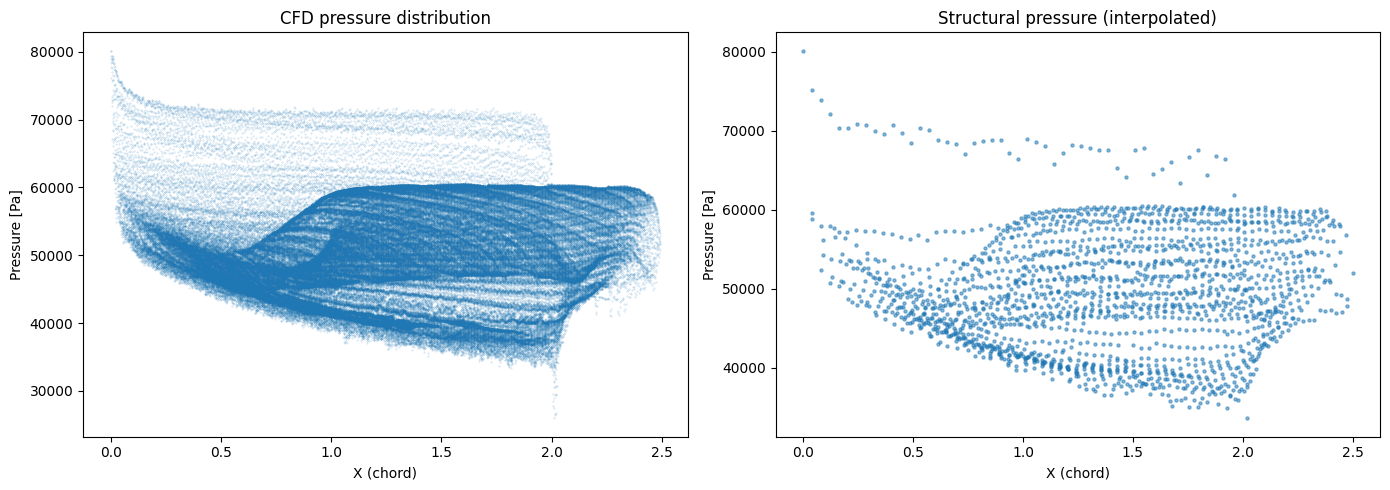

CFD min pressure at X: 2.010721
CFD min pressure at Z: -0.0047568353
Structural min pressure at X: 2.0199628723356793


In [67]:
import matplotlib.pyplot as plt

# Plot pressure theo X (chord direction)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# CFD pressure
axes[0].scatter(cfd_pts[:, 0], p_cfd, s=0.1, alpha=0.3)
axes[0].set_xlabel("X (chord)")
axes[0].set_ylabel("Pressure [Pa]")
axes[0].set_title("CFD pressure distribution")

# Structural pressure
axes[1].scatter(struct_pts[:, 0], p_struct, s=5, alpha=0.5)
axes[1].set_xlabel("X (chord)")
axes[1].set_ylabel("Pressure [Pa]")
axes[1].set_title("Structural pressure (interpolated)")

plt.tight_layout()
plt.show()

# So sánh min pressure location
print("CFD min pressure at X:", cfd_pts[np.argmin(p_cfd), 0])
print("CFD min pressure at Z:", cfd_pts[np.argmin(p_cfd), 2])
print("Structural min pressure at X:", struct_pts[np.argmin(p_struct), 0])

% normal +z (upper): 50.0
% normal -z (lower): 50.0


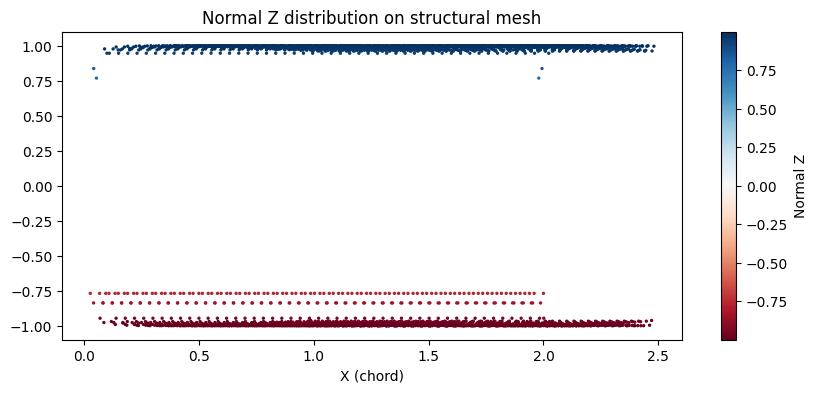

In [69]:
# Plot normal Z theo X cho structural mesh
coords = mesh.coordinates()
cells = mesh.cells()

cx, cz, nz_list = [], [], []
for i, j, k in cells:
    x0, x1, x2 = coords[i], coords[j], coords[k]
    nA = np.cross(x1-x0, x2-x0)
    nA /= np.linalg.norm(nA)
    c = (x0+x1+x2)/3
    cx.append(c[0])
    cz.append(c[2])
    nz_list.append(nA[2])

nz_arr = np.array(nz_list)
print("% normal +z (upper):", (nz_arr > 0).mean()*100)
print("% normal -z (lower):", (nz_arr < 0).mean()*100)

plt.figure(figsize=(10,4))
plt.scatter(cx, nz_list, s=2, c=nz_list, cmap='RdBu')
plt.colorbar(label='Normal Z')
plt.xlabel("X (chord)")
plt.title("Normal Z distribution on structural mesh")
plt.show()